# Geometry of Truth on PRM800K

**Pipeline:**
1. Get PRM800K data
2. Prepare dataset (parse steps, derive concept labels)
3. Extract Llama-2-7b hidden states per layer
4. Logistic regression probing per layer
5. Mass-Mean Probing (all concepts)
6. PCA visualization
7. INSIDE / EigenScore

**Requirements:** Kaggle GPU (T4 recommended), HuggingFace token for Llama-2.

In [1]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — enable GPU in Settings')
print('CUDA version:', torch.version.cuda)

GPU: Tesla T4
CUDA version: 12.8


In [2]:
!pip install -q transformers accelerate bitsandbytes pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00


In [ ]:
import os

from kaggle_secrets import UserSecretsClient
os.environ['HF_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')
os.environ['HF_CACHE_DIR'] = '/kaggle/working/hf_cache'

In [4]:
!git clone https://github.com/Nimbleredsquirrel/LingueTech.git
%cd LingueTech

Cloning into 'LingueTech'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 61 (delta 31), reused 20 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 36.04 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/kaggle/working/LingueTech


In [5]:
# get PRM800K dataset
!git lfs install
!git clone https://github.com/openai/prm800k.git
!mkdir -p data
!cp prm800k/prm800k/data/phase2_train.jsonl data/phase2_train.jsonl
!echo 'PRM800K lines:' $(wc -l < data/phase2_train.jsonl)

Updated git hooks.
Git LFS initialized.
Cloning into 'prm800k'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 28 (delta 1), reused 0 (delta 0), pack-reused 20 (from 1)
Receiving objects: 100% (28/28), 4.86 MiB | 33.43 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Filtering content: 100% (6/6), 465.82 MiB | 13.23 MiB/s, done.
PRM800K lines: 97782


In [6]:
# step 1: parse PRM800K → dataset.parquet (+ concept columns)
!python prepare_dataset.py

Saved 5000 rows to data/dataset.parquet
Labels: {1: 3656, 0: 1344}


In [7]:
import pandas as pd
df = pd.read_parquet('data/dataset.parquet')
print('shape:', df.shape)
print('columns:', df.columns.tolist())
print('labels:', df['label'].value_counts().to_dict())
df.head(3)

shape: (5000, 10)
columns: ['text', 'prompt', 'label', 'has_equation', 'is_long_step', 'has_conclusion_word', 'has_certainty', 'has_hedging', 'has_negation', 'has_error_word']
labels: {1: 3656, 0: 1344}


,text,prompt,label,has_equation,is_long_step,has_conclusion_word,has_certainty,has_hedging,has_negation,has_error_word
0,"Problem: If $\frac{\sin (2A + B)}{\sin B} = 5,...","Problem: If $\frac{\sin (2A + B)}{\sin B} = 5,...",1,1,0,0,0,0,0,0
1,Problem: Compute the smallest positive integer...,Problem: Compute the smallest positive integer...,1,1,0,0,0,0,0,0
2,Problem: The real root of the equation $8x^3 -...,Problem: The real root of the equation $8x^3 -...,0,1,1,0,0,0,0,0


In [8]:
# step 2: extract hidden states — saves layers/layer{1..33}.csv
!python extract_hidden_states.py

tokenizer_config.json: 100%|███████████████████| 776/776 [00:00<00:00, 4.17MB/s]
tokenizer.json: 1.84MB [00:00, 27.3MB/s]
tokenizer.model: 100%|███████████████████████| 500k/500k [00:00<00:00, 1.54MB/s]
special_tokens_map.json: 100%|█████████████████| 414/414 [00:00<00:00, 3.39MB/s]
model.safetensors.index.json: 26.8kB [00:00, 77.6MB/s]
Fetching 2 files: 100%|███████████████████████████| 2/2 [00:54<00:00, 27.17s/it]
Download complete:  91%|██████████████████  | 12.2G/13.5G [00:57<00:12, 102MB/s]The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Download complete: 100%|███████████████████| 13.5G/13.5G [00:58<00:00, 8.33MB/s]
Loading weights:   0%|                                  | 0/291 [00:00<?, ?it/s]
Loading weights:   0%| | 1/291 [00:00<00:00, 7796.10it/s, Materializing param=lm
Loading weights:   0%| | 1/291 [00:00<00:00, 3063.77it/s, Materializing param=lm
Loading weights:   1%| | 2/291 [0

In [9]:
# step 3: logistic regression probing per layer
!python probing.py

Layer  1  acc=0.7278  f1=0.8407  roc_auc=0.5880
Layer  2  acc=0.7288  f1=0.8396  roc_auc=0.6498
Layer  3  acc=0.7306  f1=0.8386  roc_auc=0.6558
Layer  4  acc=0.7242  f1=0.8322  roc_auc=0.6728
Layer  5  acc=0.7308  f1=0.8329  roc_auc=0.6876
Layer  6  acc=0.7228  f1=0.8225  roc_auc=0.6944
Layer  7  acc=0.7152  f1=0.8145  roc_auc=0.6954
Layer  8  acc=0.7112  f1=0.8089  roc_auc=0.7015
Layer  9  acc=0.7162  f1=0.8108  roc_auc=0.7021
Layer 10  acc=0.7094  f1=0.8052  roc_auc=0.6955
Layer 11  acc=0.7132  f1=0.8059  roc_auc=0.6960
Layer 12  acc=0.7072  f1=0.8006  roc_auc=0.6881
Layer 13  acc=0.7104  f1=0.8024  roc_auc=0.6934
Layer 14  acc=0.6956  f1=0.7917  roc_auc=0.6791
Layer 15  acc=0.7046  f1=0.7988  roc_auc=0.6904
Layer 16  acc=0.7010  f1=0.7955  roc_auc=0.6857
Layer 17  acc=0.7036  f1=0.7982  roc_auc=0.6800
Layer 18  acc=0.7000  f1=0.7943  roc_auc=0.6735
Layer 19  acc=0.6962  f1=0.7911  roc_auc=0.6755
Layer 20  acc=0.6962  f1=0.7917  roc_auc=0.6770
Layer 21  acc=0.6884  f1=0.7865  roc_auc

In [10]:
import pandas as pd
results = pd.read_csv('data/probing_results.csv')
print(results[['layer','accuracy_mean','f1_mean','roc_auc_mean']].to_string(index=False))

 layer  accuracy_mean  f1_mean  roc_auc_mean
     1         0.7278   0.8407        0.5880
     2         0.7288   0.8396        0.6498
     3         0.7306   0.8386        0.6558
     4         0.7242   0.8322        0.6728
     5         0.7308   0.8329        0.6876
     6         0.7228   0.8225        0.6944
     7         0.7152   0.8145        0.6954
     8         0.7112   0.8089        0.7015
     9         0.7162   0.8108        0.7021
    10         0.7094   0.8052        0.6955
    11         0.7132   0.8059        0.6960
    12         0.7072   0.8006        0.6881
    13         0.7104   0.8024        0.6934
    14         0.6956   0.7917        0.6791
    15         0.7046   0.7988        0.6904
    16         0.7010   0.7955        0.6857
    17         0.7036   0.7982        0.6800
    18         0.7000   0.7943        0.6735
    19         0.6962   0.7911        0.6755
    20         0.6962   0.7917        0.6770
    21         0.6884   0.7865        0.6685
    22    

In [11]:
# step 4: mass-mean probing for all concepts (label + epistemic markers)
!python mass_mean_probe.py --all


Probing concept: 'label'
  Layer  1  MM=0.5795  LDA=0.5825
  Layer  2  MM=0.5927  LDA=0.5559
  Layer  3  MM=0.6111  LDA=0.5420
  Layer  4  MM=0.6145  LDA=0.5221
  Layer  5  MM=0.6213  LDA=0.5155
  Layer  6  MM=0.6364  LDA=0.5226
  Layer  7  MM=0.6435  LDA=0.5205
  Layer  8  MM=0.6503  LDA=0.5373
  Layer  9  MM=0.6535  LDA=0.5350
  Layer 10  MM=0.6568  LDA=0.5159
  Layer 11  MM=0.6681  LDA=0.5218
  Layer 12  MM=0.6671  LDA=0.5261
  Layer 13  MM=0.6718  LDA=0.5410
  Layer 14  MM=0.6745  LDA=0.5320
  Layer 15  MM=0.6658  LDA=0.5305
  Layer 16  MM=0.6513  LDA=0.5164
  Layer 17  MM=0.6285  LDA=0.5355
  Layer 18  MM=0.6069  LDA=0.5242
  Layer 19  MM=0.5783  LDA=0.5309
  Layer 20  MM=0.5655  LDA=0.5303
  Layer 21  MM=0.5611  LDA=0.5434
  Layer 22  MM=0.5468  LDA=0.5284
  Layer 23  MM=0.5409  LDA=0.5339
  Layer 24  MM=0.5365  LDA=0.5362
  Layer 25  MM=0.5371  LDA=0.5290
  Layer 26  MM=0.5329  LDA=0.5264
  Layer 27  MM=0.5338  LDA=0.5261
  Layer 28  MM=0.5256  LDA=0.5083
  Layer 29  MM=0.5321 

Saved plots/pca_layer1.png
Saved plots/pca_layer6.png
Saved plots/pca_layer11.png
Saved plots/pca_layer16.png
Saved plots/pca_layer21.png
Saved plots/pca_layer26.png
Saved plots/pca_layer32.png
Saved plots/roc_auc_curve.png


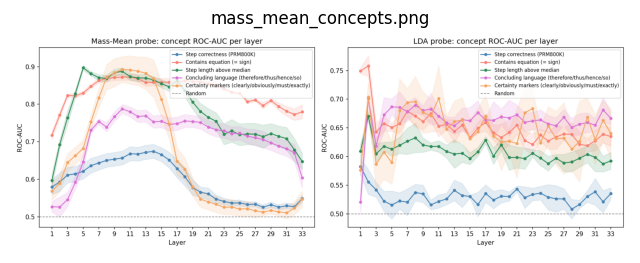

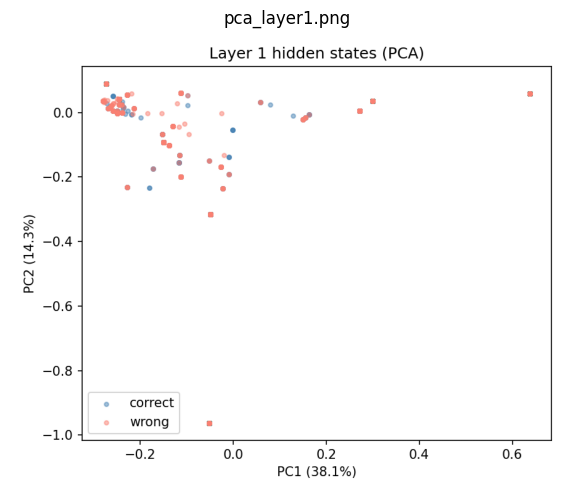

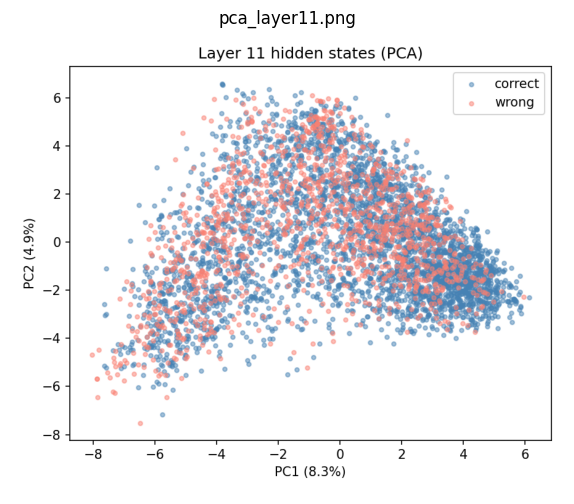

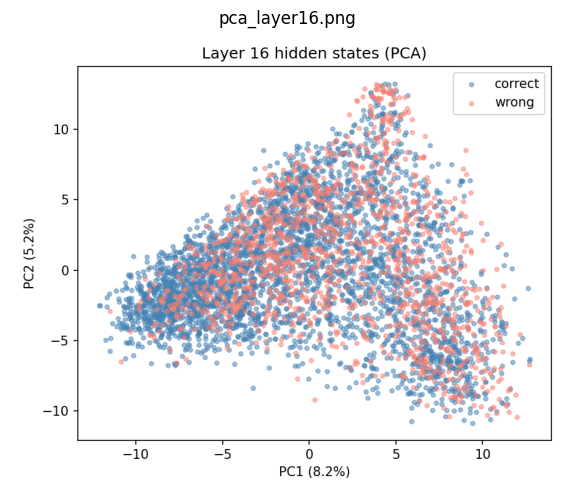

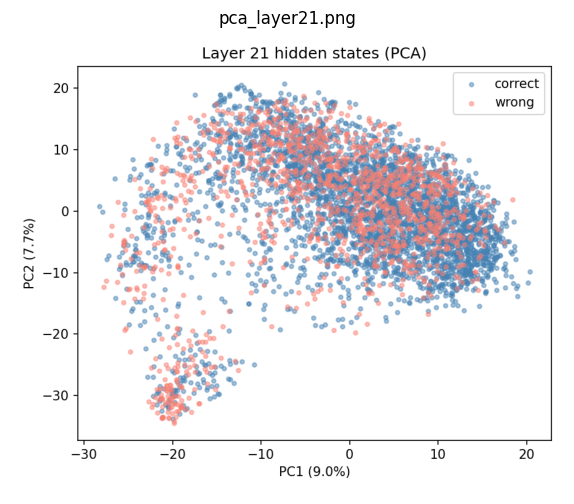

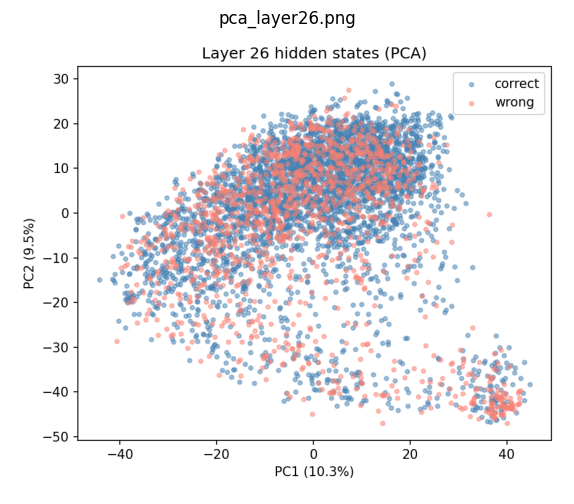

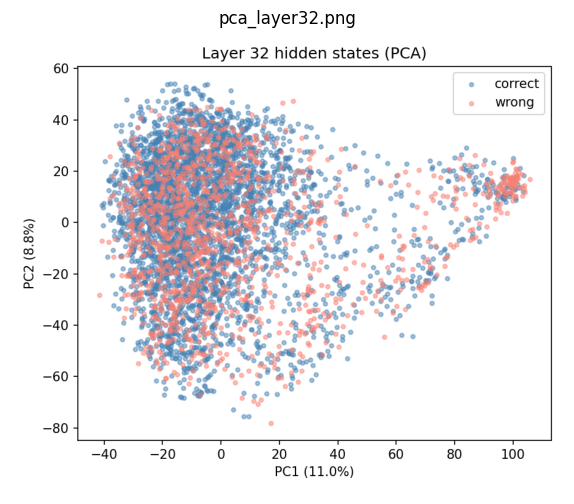

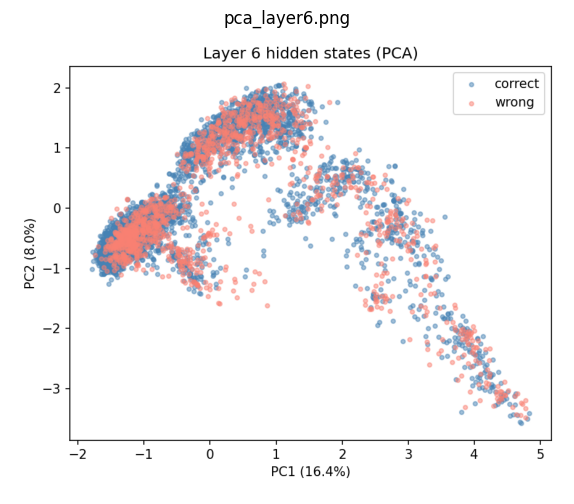

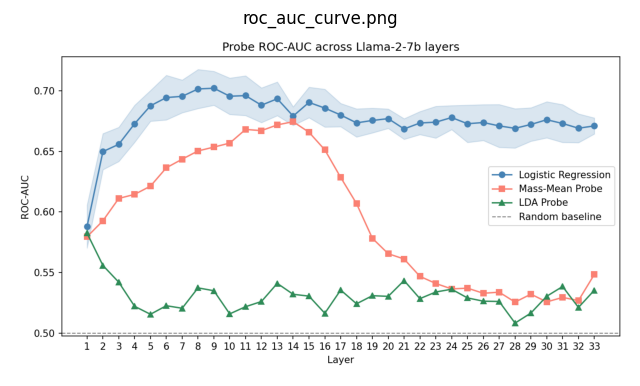

In [12]:
# step 5: PCA visualization + ROC-AUC curves
!python pca_viz.py

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

for fname in sorted(os.listdir('plots')):
    img = mpimg.imread(f'plots/{fname}')
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(fname)
    plt.show()